# Notebook 2: Feature Engineering
### NIFTY-50 Investment Intelligence Platform

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from src.data_loader import load_stock, get_symbol_list, get_sector_map, get_daily_returns
from src.indicators import add_all_indicators

plt.rcParams.update({'figure.dpi': 120, 'font.size': 11,
                     'axes.spines.top': False, 'axes.spines.right': False})
os.makedirs('../report', exist_ok=True)
print("Imports OK")

Imports OK


## 1. Build Feature-Engineered Dataset for All Stocks

In [2]:
def build_features(symbol: str, horizon: int = 5) -> pd.DataFrame:
    """
    Load a stock, add all indicators, add lag features,
    add calendar features, and return clean ML-ready DataFrame.
    """
    df = load_stock(symbol)
    df = add_all_indicators(df, target_horizon=horizon)

    # ── Calendar features ─────────────────────────────────────
    df['DayOfWeek']  = df['Date'].dt.dayofweek
    df['Month']      = df['Date'].dt.month
    df['Quarter']    = df['Date'].dt.quarter
    df['WeekOfYear'] = df['Date'].dt.isocalendar().week.astype(int)
    df['IsMonthEnd'] = df['Date'].dt.is_month_end.astype(int)

    # ── Additional lag features ────────────────────────────────
    for lag in [1, 2, 3, 5, 10]:
        df[f'Close_Lag_{lag}'] = df['Close'].shift(lag)
        df[f'Volume_Lag_{lag}'] = df['Volume'].shift(lag)

    # ── Price relative to moving averages ──────────────────────
    df['Price_vs_SMA20']  = (df['Close'] - df['SMA_20'])  / df['SMA_20']  * 100
    df['Price_vs_SMA50']  = (df['Close'] - df['SMA_50'])  / df['SMA_50']  * 100
    df['Price_vs_SMA200'] = (df['Close'] - df['SMA_200']) / df['SMA_200'] * 100

    # ── Trend signals ──────────────────────────────────────────
    df['Golden_Cross'] = ((df['SMA_50'] > df['SMA_200']) &
                          (df['SMA_50'].shift(1) <= df['SMA_200'].shift(1))).astype(int)
    df['Death_Cross']  = ((df['SMA_50'] < df['SMA_200']) &
                          (df['SMA_50'].shift(1) >= df['SMA_200'].shift(1))).astype(int)
    df['Bull_Trend']   = (df['SMA_50'] > df['SMA_200']).astype(int)

    # ── RSI signals ────────────────────────────────────────────
    df['RSI_Overbought']  = (df['RSI'] > 70).astype(int)
    df['RSI_Oversold']    = (df['RSI'] < 30).astype(int)

    # ── MACD signal crossover ──────────────────────────────────
    df['MACD_Bullish'] = ((df['MACD'] > df['MACD_Signal']) &
                          (df['MACD'].shift(1) <= df['MACD_Signal'].shift(1))).astype(int)

    # ── Volume spike ──────────────────────────────────────────
    df['Volume_Spike'] = (df['Volume_Ratio'] > 2.0).astype(int)

    # ── Symbol column for multi-stock merge ───────────────────
    df['Symbol'] = symbol

    # Drop rows that still have NaN in feature columns
    feature_cols = [c for c in df.columns if c not in ['Date', 'Symbol']]
    df = df.dropna(subset=feature_cols[:20])   # require first 20 features non-null
    df = df.reset_index(drop=True)
    return df

# Test on RELIANCE
df_test = build_features('RELIANCE')
print(f"RELIANCE feature shape: {df_test.shape}")
print(f"Columns ({len(df_test.columns)}):")
print(df_test.columns.tolist())

RELIANCE feature shape: (5107, 78)
Columns (78):
['Date', 'Symbol', 'Open', 'High', 'Low', 'Close', 'VWAP', 'Volume', 'Turnover', 'SMA_20', 'SMA_50', 'SMA_200', 'EMA_12', 'EMA_26', 'EMA_50', 'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist', 'BB_Upper', 'BB_Middle', 'BB_Lower', 'BB_Width', 'BB_Pct', 'ATR', 'HV_21', 'Stoch_K', 'Stoch_D', 'ROC_12', 'Williams_R', 'OBV', 'VWAP_Dev', 'Volume_SMA', 'Volume_Ratio', 'ADX', 'Plus_DI', 'Minus_DI', 'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d', 'High_Low_Range', 'Open_Close_Range', 'Rolling_Std_5', 'Rolling_Mean_5', 'Rolling_Std_10', 'Rolling_Mean_10', 'Rolling_Std_20', 'Rolling_Mean_20', 'Gap_Up', 'Gap_Down', 'Future_Return_5d', 'Direction_5d', 'DayOfWeek', 'Month', 'Quarter', 'WeekOfYear', 'IsMonthEnd', 'Close_Lag_1', 'Volume_Lag_1', 'Close_Lag_2', 'Volume_Lag_2', 'Close_Lag_3', 'Volume_Lag_3', 'Close_Lag_5', 'Volume_Lag_5', 'Close_Lag_10', 'Volume_Lag_10', 'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200', 'Golden_Cross', 'Death_Cross', 'Bu

In [3]:
# Build dataset for all stocks
symbols = get_symbol_list()
sector_map = get_sector_map()
all_dfs = []

for sym in symbols:
    try:
        df_s = build_features(sym)
        df_s['Sector'] = sector_map.get(sym, 'Unknown')
        all_dfs.append(df_s)
    except Exception as e:
        print(f"Skipping {sym}: {e}")

master_df = pd.concat(all_dfs, ignore_index=True)
print(f"\nMaster dataset shape: {master_df.shape}")
print(f"Stocks included: {master_df['Symbol'].nunique()}")
print(f"Date range: {master_df['Date'].min().date()} → {master_df['Date'].max().date()}")
print(f"\nTarget column sample:")
print(master_df[['Symbol','Date','Close','Future_Return_5d','Direction_5d']].tail(10).to_string(index=False))

Skipping INFRATEL: Can only use .dt accessor with datetimelike values

Master dataset shape: (220334, 79)
Stocks included: 48
Date range: 2000-10-19 → 2021-04-30

Target column sample:
Symbol       Date  Close  Future_Return_5d  Direction_5d
  ZEEL 2021-04-16 193.95         -3.892756             0
  ZEEL 2021-04-19 190.35         -1.155766             0
  ZEEL 2021-04-20 197.40         -4.204661             0
  ZEEL 2021-04-22 192.30         -2.990120             0
  ZEEL 2021-04-23 188.00         -1.276596             0
  ZEEL 2021-04-26 186.40               NaN             0
  ZEEL 2021-04-27 188.15               NaN             0
  ZEEL 2021-04-28 189.10               NaN             0
  ZEEL 2021-04-29 186.55               NaN             0
  ZEEL 2021-04-30 185.60               NaN             0


## 2. Feature Importance Analysis

In [4]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

# Use a broad sample: last 3 years of data across all stocks
recent = master_df[master_df['Date'] >= '2018-01-01'].copy()

FEATURE_COLS = [
    'RSI', 'MACD', 'MACD_Signal', 'MACD_Hist',
    'BB_Width', 'BB_Pct', 'ATR',
    'SMA_20', 'SMA_50', 'SMA_200',
    'EMA_12', 'EMA_26',
    'Price_vs_SMA20', 'Price_vs_SMA50', 'Price_vs_SMA200',
    'Return_1d', 'Return_5d', 'Return_10d', 'Return_20d',
    'Rolling_Std_5', 'Rolling_Std_10', 'Rolling_Std_20',
    'Volume_Ratio', 'OBV',
    'ADX', 'Stoch_K', 'Stoch_D',
    'Williams_R', 'ROC_12',
    'High_Low_Range', 'Open_Close_Range',
    'Bull_Trend', 'RSI_Overbought', 'RSI_Oversold',
    'DayOfWeek', 'Month', 'Quarter',
    'HV_21',
]

TARGET_COL = 'Direction_5d'
available_features = [f for f in FEATURE_COLS if f in recent.columns]

df_model = recent[available_features + [TARGET_COL]].dropna()
X = df_model[available_features]
y = df_model[TARGET_COL]

print(f"Training samples: {len(X)}")
print(f"Class balance: {y.value_counts(normalize=True).round(3).to_dict()}")

rf = RandomForestClassifier(n_estimators=100, max_depth=6,
                            random_state=42, n_jobs=-1)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_, index=available_features).sort_values(ascending=False)
print(f"\nTop 15 features by importance:")
print(importances.head(15).to_string())

Training samples: 39504
Class balance: {1: 0.512, 0: 0.488}

Top 15 features by importance:
Month              0.088151
Quarter            0.054357
HV_21              0.050015
OBV                0.046459
Rolling_Std_20     0.043133
Price_vs_SMA200    0.042859
SMA_50             0.039941
EMA_12             0.036478
ATR                0.035958
SMA_200            0.034978
EMA_26             0.033772
SMA_20             0.033613
Return_5d          0.031184
Rolling_Std_10     0.027554
BB_Width           0.026721


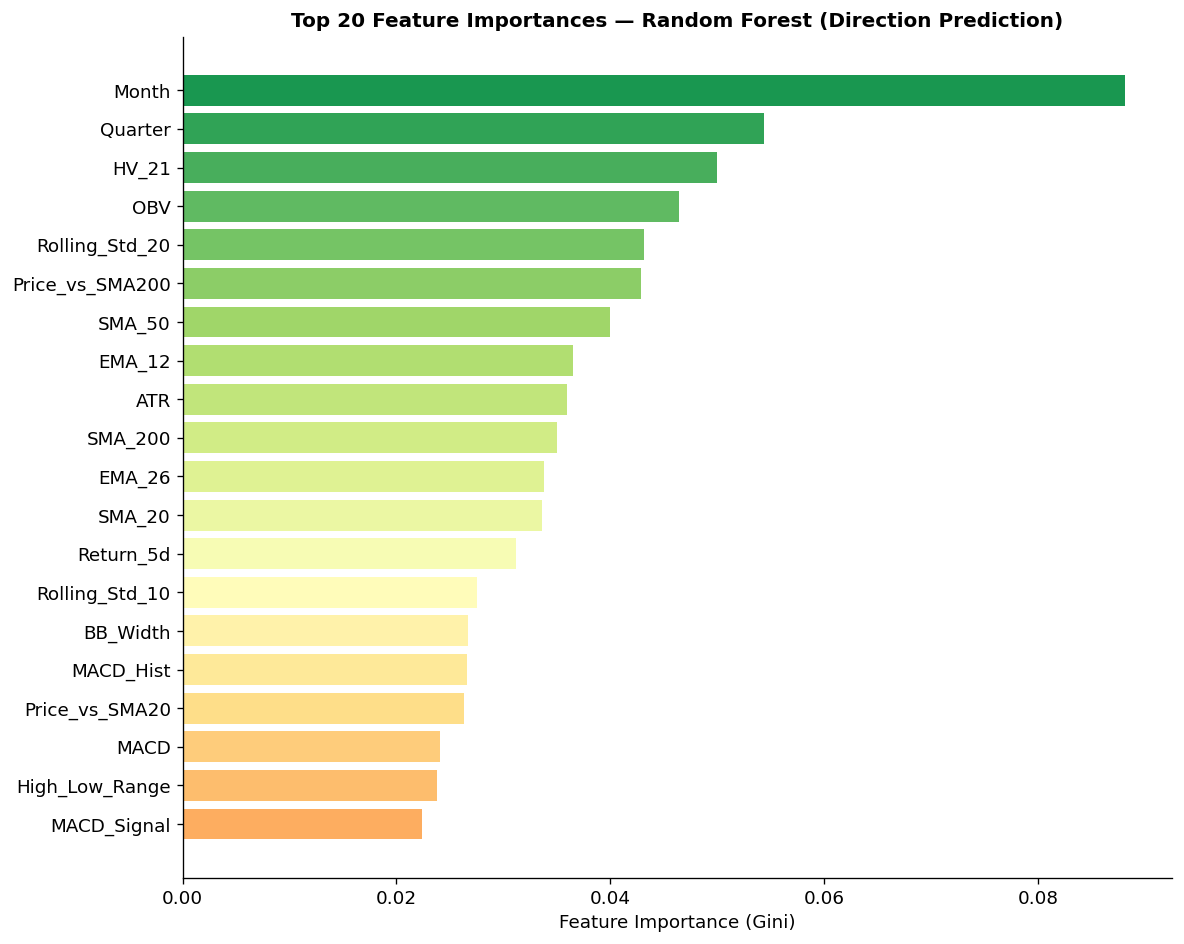

In [5]:
# Feature importance plot
fig, ax = plt.subplots(figsize=(10, 8))
top_features = importances.head(20)
colors = plt.cm.RdYlGn(np.linspace(0.3, 0.9, len(top_features)))[::-1]
ax.barh(top_features.index[::-1], top_features.values[::-1], color=colors[::-1])
ax.set_xlabel("Feature Importance (Gini)")
ax.set_title("Top 20 Feature Importances — Random Forest (Direction Prediction)", fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('../report/feature_importance.png', bbox_inches='tight')
plt.show()

## 3. Feature Correlation with Target

In [6]:
# Point-biserial correlation of each feature with Direction_5d
from scipy.stats import pointbiserialr

correlations = {}
for feat in available_features:
    try:
        sub = df_model[[feat, TARGET_COL]].dropna()
        r, p = pointbiserialr(sub[feat], sub[TARGET_COL])
        correlations[feat] = {'correlation': round(r, 4), 'p_value': round(p, 4)}
    except: pass

corr_df = pd.DataFrame(correlations).T
corr_df['abs_corr'] = corr_df['correlation'].abs()
corr_df = corr_df.sort_values('abs_corr', ascending=False)

print("Top 15 features most correlated with 5-day direction:")
print(corr_df.head(15)[['correlation','p_value']].to_string())

Top 15 features most correlated with 5-day direction:
                  correlation  p_value
Quarter                0.0524   0.0000
Month                  0.0464   0.0000
Rolling_Std_20         0.0202   0.0001
Bull_Trend            -0.0169   0.0008
Return_10d             0.0154   0.0022
Rolling_Std_10         0.0142   0.0047
High_Low_Range         0.0123   0.0147
Open_Close_Range      -0.0111   0.0280
OBV                   -0.0109   0.0302
Return_20d             0.0099   0.0499
HV_21                  0.0098   0.0504
DayOfWeek              0.0091   0.0714
BB_Pct                 0.0088   0.0819
Rolling_Std_5          0.0085   0.0928
MACD_Hist              0.0084   0.0963


## 4. Save Feature Columns List & Processed Dataset

In [7]:
import joblib

# Save the final feature list for use in predictor and portfolio modules
FINAL_FEATURES = importances.head(25).index.tolist()
print("Final selected features:")
for i, f in enumerate(FINAL_FEATURES, 1):
    print(f"  {i:2d}. {f}")

os.makedirs('../models', exist_ok=True)
joblib.dump(FINAL_FEATURES, '../models/feature_cols.pkl')
joblib.dump(available_features, '../models/all_feature_cols.pkl')
print("\nFeature lists saved to ../models/")

Final selected features:
   1. Month
   2. Quarter
   3. HV_21
   4. OBV
   5. Rolling_Std_20
   6. Price_vs_SMA200
   7. SMA_50
   8. EMA_12
   9. ATR
  10. SMA_200
  11. EMA_26
  12. SMA_20
  13. Return_5d
  14. Rolling_Std_10
  15. BB_Width
  16. MACD_Hist
  17. Price_vs_SMA20
  18. MACD
  19. High_Low_Range
  20. MACD_Signal
  21. Return_20d
  22. BB_Pct
  23. ADX
  24. Stoch_D
  25. RSI

Feature lists saved to ../models/


In [8]:
# Save master dataset (without huge lag columns to keep size manageable)
save_cols = ['Date','Symbol','Sector','Close','Volume'] + available_features + ['Future_Return_5d','Direction_5d']
save_cols = [c for c in save_cols if c in master_df.columns]
master_save = master_df[save_cols].copy()
master_save.to_parquet('../data/master_features.parquet', index=False)
print(f"Master features dataset saved: {master_save.shape}")
print(f"File size: {os.path.getsize('../data/master_features.parquet') / 1024 / 1024:.1f} MB")

Master features dataset saved: (220334, 45)
File size: 64.2 MB


## 5. Feature Engineering Summary

In [9]:
print("=" * 55)
print("FEATURE ENGINEERING SUMMARY")
print("=" * 55)
print(f"Total features engineered: {len(available_features)}")
print(f"\nFeature categories:")
print(f"  Moving averages     : SMA (20,50,200), EMA (12,26,50)")
print(f"  Momentum            : RSI, ROC, Stochastic, Williams %R")
print(f"  Trend               : MACD, ADX, Bull/Death Cross flags")
print(f"  Volatility          : BB Width, ATR, Historical Vol (21d)")
print(f"  Volume              : OBV, Volume Ratio, Volume Spike flag")
print(f"  Price ratios        : vs SMA20/50/200, H-L range, O-C range")
print(f"  Lag returns         : 1d, 5d, 10d, 20d returns + rolling stats")
print(f"  Calendar            : DayOfWeek, Month, Quarter, MonthEnd")
print(f"  Signal flags        : Golden/Death Cross, RSI O/S, MACD cross")
print(f"\nTop 5 most predictive features (by Random Forest importance):")
for i, (feat, val) in enumerate(importances.head(5).items(), 1):
    print(f"  {i}. {feat}: {val:.4f}")

FEATURE ENGINEERING SUMMARY
Total features engineered: 38

Feature categories:
  Moving averages     : SMA (20,50,200), EMA (12,26,50)
  Momentum            : RSI, ROC, Stochastic, Williams %R
  Trend               : MACD, ADX, Bull/Death Cross flags
  Volatility          : BB Width, ATR, Historical Vol (21d)
  Volume              : OBV, Volume Ratio, Volume Spike flag
  Price ratios        : vs SMA20/50/200, H-L range, O-C range
  Lag returns         : 1d, 5d, 10d, 20d returns + rolling stats
  Calendar            : DayOfWeek, Month, Quarter, MonthEnd
  Signal flags        : Golden/Death Cross, RSI O/S, MACD cross

Top 5 most predictive features (by Random Forest importance):
  1. Month: 0.0882
  2. Quarter: 0.0544
  3. HV_21: 0.0500
  4. OBV: 0.0465
  5. Rolling_Std_20: 0.0431
